In [1]:
# import required packages

import requests
import pandas as pd
import numpy as np
import json
from pathlib import Path
from urllib.parse import urlencode
from numbers import Integral, Real
from IPython.display import display

BASE_URL = "https://covidmod.isi.jhu.edu/api"
SITE_URL = "https://covidmod.isi.jhu.edu"
EXPORT_DIR = Path("delineo_exports")
SESSION = requests.Session()

In [2]:
def policy(hour, masking=0, vaccinated=0, lockdown=0, self_isolation=0):
    return dict(hour=hour, masking=masking, vaccinated=vaccinated,
                lockdown=lockdown, self_isolation=self_isolation)

LEGACY_RUN = {
    "run_id": 187, "label": "existing_187_parameters_unverified",
    "initial": None, "interventions": None, "other_params": {},
}

RUNS = [
    {"run_id": 187, "label": "B0", "initial": policy(0),
     "interventions": []},
    {"run_id": 188, "label": "M50-H12", "initial": policy(0),
     "interventions": [policy(12, masking=50)]},
    {"run_id": 189, "label": "V50-H12", "initial": policy(0),
     "interventions": [policy(12, vaccinated=50)]},
    {"run_id": 190, "label": "L50-H12", "initial": policy(0),
     "interventions": [policy(12, lockdown=50)]},
    {"run_id": 191, "label": "I50-H12", "initial": policy(0),
     "interventions": [policy(12, self_isolation=50)]},
    {"run_id": 192, "label": "MV50-H12", "initial": policy(0),
     "interventions": [policy(12, masking=50, vaccinated=50)]},
    {"run_id": 193, "label": "LI50-H12", "initial": policy(0),
     "interventions": [policy(12, lockdown=50, self_isolation=50)]},
    {"run_id": 194, "label": "ALL50-H12", "initial": policy(0),
     "interventions": [policy(12, masking=50, vaccinated=50, lockdown=50, self_isolation=50)]},
    {"run_id": 195, "label": "V50-H72", "initial": policy(0),
     "interventions": [policy(72, vaccinated=50)]},
    {"run_id": 196, "label": "V50-H168", "initial": policy(0),
     "interventions": [policy(168, vaccinated=50)]},
]

# Optional: add other_params to each run to record its actual random_seed, initial_infected, etc.
# To analyze the previous run: RUNS.append(LEGACY_RUN)
SELECTED_LABEL = "B0"
SNAPSHOT_API_TIME = None  # None = the last snapshot of the selected run; alternatively, use a value from its timesteps.

In [3]:
PERCENT_FIELDS = ("masking", "vaccinated", "lockdown", "self_isolation")

def checked_integer(value, name, minimum=0):
    if isinstance(value, bool) or not isinstance(value, Integral) or value < minimum:
        raise ValueError(f"{name} must be an integer >= {minimum}; received {value!r}")
    return int(value)

def validate_policy(p, initial=False):
    h = checked_integer(p["hour"], "hour", 0 if initial else 1)
    if initial and h != 0:
        raise ValueError("The initial policy hour must be 0")
    for key in PERCENT_FIELDS:
        v = p[key]
        if isinstance(v, bool) or not isinstance(v, Real) or not 0 <= v <= 100:
            raise ValueError(f"{key} must be between 0 and 100")

def validate_runs(runs):
    seen = set()
    for run in runs:
        rid = checked_integer(run["run_id"], "run_id", 1)
        if rid in seen:
            raise ValueError(f"Duplicate run_id: {rid}")
        seen.add(rid)
        if run.get("initial") is not None:
            validate_policy(run["initial"], initial=True)
        interventions = run.get("interventions")
        if interventions is not None:
            hours = []
            for p in interventions:
                validate_policy(p)
                hours.append(p["hour"])
            if hours != sorted(set(hours)):
                raise ValueError(f"run {rid} must have strictly increasing, unique intervention times")

def run_urls(run_id):
    rid = checked_integer(run_id, "run_id", 1)
    return {
        "result_url": f"{SITE_URL}/simulator/{rid}",
        "chart_url": f"{BASE_URL}/simdata/{rid}/chartdata",
        "map_url": f"{BASE_URL}/simdata/{rid}/map",
    }

def snapshot_url(run_id, time):
    # time is an API timestamp from map_data['timesteps'], not an intervention hour.
    time = checked_integer(time, "API time")
    return run_urls(run_id)["map_url"] + "?" + urlencode({"time": time})

def make_run_table(runs):
    validate_runs(runs)
    rows = []
    for run in runs:
        rows.append({
            "run_id": run["run_id"],
            "label": run.get("label", f"run_{run['run_id']}"),
            "initial": json.dumps(run.get("initial"), ensure_ascii=False),
            "interventions": json.dumps(run.get("interventions"), ensure_ascii=False),
            "other_params": json.dumps(run.get("other_params", {}), ensure_ascii=False),
            **run_urls(run["run_id"]),
        })
    return pd.DataFrame(rows)


def fetch_json(url, timeout=60):
    response = SESSION.get(url, timeout=timeout)
    response.raise_for_status()
    payload = response.json()
    if not isinstance(payload, dict) or "data" not in payload:
        raise ValueError(f"Response is missing the data field: {url}")
    return payload

def load_run(run_id):
    urls = run_urls(run_id)
    return {
        "run_id": run_id,
        "urls": urls,
        "chart_json": fetch_json(urls["chart_url"]),
        "map_json": fetch_json(urls["map_url"]),
    }

def get_snapshot(run_id, time):
    return fetch_json(snapshot_url(run_id, time))["data"]

In [4]:
labels = [r["label"] for r in RUNS]
if len(labels) != len(set(labels)):
    raise ValueError("Duplicate labels: use a unique label for each simulation replicate")
active_runs = [r for r in RUNS if r.get("run_id") is not None]
pending = [r["label"] for r in RUNS if r.get("run_id") is None]
print("Runs awaiting IDs: ", pending or "None")
if not active_runs:
    raise ValueError("Enter at least one actual run_id in RUNS, then resume from this cell")
run_table = make_run_table(active_runs)
with pd.option_context("display.max_colwidth", None):
    display(run_table[["label", "run_id", "chart_url", "map_url", "result_url"]])
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
run_table.to_csv(EXPORT_DIR / "run_request_urls.csv", index=False, encoding="utf-8-sig")
(EXPORT_DIR / "run_registry.json").write_text(
    json.dumps(RUNS, ensure_ascii=False, indent=2), encoding="utf-8")

Runs awaiting IDs:  None


,label,run_id,chart_url,map_url,result_url
0,B0,187,https://covidmod.isi.jhu.edu/api/simdata/187/chartdata,https://covidmod.isi.jhu.edu/api/simdata/187/map,https://covidmod.isi.jhu.edu/simulator/187
1,M50-H12,188,https://covidmod.isi.jhu.edu/api/simdata/188/chartdata,https://covidmod.isi.jhu.edu/api/simdata/188/map,https://covidmod.isi.jhu.edu/simulator/188
2,V50-H12,189,https://covidmod.isi.jhu.edu/api/simdata/189/chartdata,https://covidmod.isi.jhu.edu/api/simdata/189/map,https://covidmod.isi.jhu.edu/simulator/189
3,L50-H12,190,https://covidmod.isi.jhu.edu/api/simdata/190/chartdata,https://covidmod.isi.jhu.edu/api/simdata/190/map,https://covidmod.isi.jhu.edu/simulator/190
4,I50-H12,191,https://covidmod.isi.jhu.edu/api/simdata/191/chartdata,https://covidmod.isi.jhu.edu/api/simdata/191/map,https://covidmod.isi.jhu.edu/simulator/191
5,MV50-H12,192,https://covidmod.isi.jhu.edu/api/simdata/192/chartdata,https://covidmod.isi.jhu.edu/api/simdata/192/map,https://covidmod.isi.jhu.edu/simulator/192
6,LI50-H12,193,https://covidmod.isi.jhu.edu/api/simdata/193/chartdata,https://covidmod.isi.jhu.edu/api/simdata/193/map,https://covidmod.isi.jhu.edu/simulator/193
7,ALL50-H12,194,https://covidmod.isi.jhu.edu/api/simdata/194/chartdata,https://covidmod.isi.jhu.edu/api/simdata/194/map,https://covidmod.isi.jhu.edu/simulator/194
8,V50-H72,195,https://covidmod.isi.jhu.edu/api/simdata/195/chartdata,https://covidmod.isi.jhu.edu/api/simdata/195/map,https://covidmod.isi.jhu.edu/simulator/195
9,V50-H168,196,https://covidmod.isi.jhu.edu/api/simdata/196/chartdata,https://covidmod.isi.jhu.edu/api/simdata/196/map,https://covidmod.isi.jhu.edu/simulator/196


3338

In [5]:
REFRESH_CACHE = False
CACHE_DIR = EXPORT_DIR / "raw"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
loaded_runs = {}
for run in active_runs:
    rid = run["run_id"]
    path = CACHE_DIR / f"run_{rid}.json"
    if path.exists() and not REFRESH_CACHE:
        data = json.loads(path.read_text(encoding="utf-8"))
        if data.get("run_id") != rid:
            raise ValueError(f"Cache ID mismatch: {path}")
    else:
        data = load_run(rid)
        path.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
    data["label"] = run["label"]
    data["params"] = run
    loaded_runs[rid] = data
    print(f"Loaded {run['label']} / run {rid}")

rows = []
for rid, entry in loaded_runs.items():
    m = entry["map_json"]["data"]
    ts = m["timesteps"]
    if not ts:
        raise ValueError(f"run {rid} has no timesteps")
    rows.append(dict(label=entry["label"], run_id=rid,
                     n_homes=len(m["papdata"]["homes"]),
                     n_places=len(m["papdata"]["places"]),
                     n_timesteps=len(ts), first_api_time=ts[0], last_api_time=ts[-1]))
overview = pd.DataFrame(rows)
display(overview)
overview.to_csv(EXPORT_DIR / "run_overview.csv", index=False, encoding="utf-8-sig")

Loaded B0 / run 187
Loaded M50-H12 / run 188
Loaded V50-H12 / run 189
Loaded L50-H12 / run 190
Loaded I50-H12 / run 191
Loaded MV50-H12 / run 192
Loaded LI50-H12 / run 193
Loaded ALL50-H12 / run 194
Loaded V50-H72 / run 195
Loaded V50-H168 / run 196


,label,run_id,n_homes,n_places,n_timesteps,first_api_time,last_api_time
0,B0,187,21433,3180,720,60,43200
1,M50-H12,188,21433,3180,720,60,43200
2,V50-H12,189,21433,3180,720,60,43200
3,L50-H12,190,21433,3180,720,60,43200
4,I50-H12,191,21433,3180,720,60,43200
5,MV50-H12,192,21433,3180,720,60,43200
6,LI50-H12,193,21433,3180,720,60,43200
7,ALL50-H12,194,21433,3180,720,60,43200
8,V50-H72,195,21433,3180,720,60,43200
9,V50-H168,196,21433,3180,720,60,43200


In [6]:
matches = [r for r in active_runs if r["label"] == SELECTED_LABEL]
if not matches:
    raise ValueError(f"Enter the ID for {SELECTED_LABEL}, or change SELECTED_LABEL")
RUN_ID = matches[0]["run_id"]
entry = loaded_runs[RUN_ID]
chart_json = entry["chart_json"]
map_data = entry["map_json"]["data"]
timesteps = map_data["timesteps"]
snapshot_urls = pd.DataFrame({
    "run_id": RUN_ID, "api_time": timesteps,
    "snapshot_url": [snapshot_url(RUN_ID, t) for t in timesteps],
})
snapshot_urls.to_csv(EXPORT_DIR / f"run_{RUN_ID}_snapshot_urls.csv",
                     index=False, encoding="utf-8-sig")
display(snapshot_urls.head())
requested_t = timesteps[-1] if SNAPSHOT_API_TIME is None else SNAPSHOT_API_TIME
if requested_t not in timesteps:
    raise ValueError("SNAPSHOT_API_TIME is not in this run's timesteps")
snapshot = get_snapshot(RUN_ID, requested_t)
t = snapshot["time"]
frame = snapshot["simdata"][str(t)]
print(f"run {RUN_ID} / requested time {requested_t} / returned time {t}")

homes_df = pd.DataFrame(map_data["papdata"]["homes"])
places_df = pd.DataFrame(map_data["papdata"]["places"])
homes_df.insert(0, "home_index", range(len(homes_df)))
places_df.insert(0, "place_index", range(len(places_df)))
for field, expected in [("h", 2*len(homes_df)), ("p", 2*len(places_df)),
                        ("pinc", len(places_df))]:
    if len(frame[field]) != expected:
        raise ValueError(f"{field} length mismatch: expected {expected}, got {len(frame[field])}")
h_arr = np.asarray(frame["h"]).reshape(-1, 2)
p_arr = np.asarray(frame["p"]).reshape(-1, 2)
poi_t = places_df.assign(run_id=RUN_ID, time=t,
                         population_present=p_arr[:, 0],
                         infected_present=p_arr[:, 1],
                         pinc_raw=np.asarray(frame["pinc"]))
display(pd.DataFrame([{
    "run_id": RUN_ID, "api_time": t,
    "people_at_POIs": poi_t["population_present"].sum(),
    "infected_at_POIs": poi_t["infected_present"].sum(),
    "pinc_raw_sum": poi_t["pinc_raw"].sum(),
}]))
display(poi_t.sort_values("population_present", ascending=False).head(20))

,run_id,api_time,snapshot_url
0,187,60,https://covidmod.isi.jhu.edu/api/simdata/187/m...
1,187,120,https://covidmod.isi.jhu.edu/api/simdata/187/m...
2,187,180,https://covidmod.isi.jhu.edu/api/simdata/187/m...
3,187,240,https://covidmod.isi.jhu.edu/api/simdata/187/m...
4,187,300,https://covidmod.isi.jhu.edu/api/simdata/187/m...


run 187 / requested time 43200 / returned time 43200


,run_id,api_time,people_at_POIs,infected_at_POIs,pinc_raw_sum
0,187,43200,4230,1,0


,place_index,id,placekey,latitude,longitude,label,top_category,footprint,run_id,time,population_present,infected_present,pinc_raw
2854,2854,2854,zzw-222@5r8-fr4-nkf,36.199099,-95.884725,Tulsa International Airport,Support Activities for Air Transportation,"{'type': 'Polygon', 'coordinates': [[[-95.9073...",187,43200,310,0,0
116,116,116,zzy-222@5r8-fr2-28v,36.209692,-95.875590,Subway,Restaurants and Other Eating Places,"{'type': 'Polygon', 'coordinates': [[[-95.8738...",187,43200,289,0,0
2396,2396,2396,zzw-222@5r8-g3t-yjv,36.369004,-96.053955,Osage Casino Hotel Skiatook,Gambling Industries,"{'type': 'Polygon', 'coordinates': [[[-96.0552...",187,43200,181,0,0
1088,1088,1088,zzw-222@5r8-dxs-ysq,36.750451,-95.977948,Gpm Duke Energy Field Services,Gasoline Stations,"{'type': 'Polygon', 'coordinates': [[[-95.9777...",187,43200,175,0,0
2338,2338,2338,zzy-222@5r8-fgu-575,36.185509,-95.877241,Quik Trip,Grocery Stores,"{'type': 'Polygon', 'coordinates': [[[-95.8765...",187,43200,134,0,0
341,341,341,222-222@5r8-fr2-2x5,36.203682,-95.872365,Champs Chicken,Restaurants and Other Eating Places,"{'type': 'Polygon', 'coordinates': [[[-95.8716...",187,43200,132,0,0
1449,1449,1449,225-224@5r8-f28-f75,36.751356,-95.938313,Ascension Jane Phillips Medical Center,Offices of Physicians,"{'type': 'Polygon', 'coordinates': [[[-95.9384...",187,43200,111,0,0
664,664,664,zzw-222@5r8-fbr-wkz,36.281157,-95.862393,Bailey Ranch Golf Club,Other Amusement and Recreation Industries,"{'type': 'MultiPolygon', 'coordinates': [[[[-9...",187,43200,102,0,0
2098,2098,2098,225-225@5r8-f28-f75,36.751864,-95.938217,Ascension St John Clinic Urgent Care Bartlesville,Outpatient Care Centers,"{'type': 'Polygon', 'coordinates': [[[-95.9384...",187,43200,101,0,0
715,715,715,222-223@5r8-g3v-49z,36.369464,-96.053801,Osage Casino,Gambling Industries,"{'type': 'Polygon', 'coordinates': [[[-96.0532...",187,43200,93,0,0


In [7]:
def preview(value, limit=3):
    if isinstance(value, dict):
        return {k: preview(v, limit) for k, v in list(value.items())[:limit]}
    if isinstance(value, list):
        return [preview(v, limit) for v in value[:limit]]
    return value

chart_data = chart_json["data"]
for key in ("states", "iot", "metadata"):
    value = chart_data.get(key)
    print(key, "type:", type(value).__name__)
    print(json.dumps(preview(value), ensure_ascii=False, indent=2))

states type: list
[
  {
    "time": 1,
    "Removed": 0,
    "Infected": 1
  },
  {
    "time": 2,
    "Removed": 0,
    "Infected": 1
  },
  {
    "time": 3,
    "Removed": 0,
    "Infected": 1
  }
]
iot type: list
[
  {
    "time": 1,
    "Delta": 1
  },
  {
    "time": 2,
    "Delta": 1
  },
  {
    "time": 3,
    "Delta": 1
  }
]
metadata type: dict
{
  "dmp_mode": "auto",
  "randseed": true,
  "variants": [
    "Delta"
  ]
}


In [8]:
# Display all fields without truncating each record
for rid, entry in loaded_runs.items():
    records = entry["chart_json"]["data"]["states"]
    fields = sorted({key for record in records for key in record})
    print(entry["label"], rid, fields)

# Combine states data from the ten runs while preserving provenance
frames = []

for rid, entry in loaded_runs.items():
    df = pd.DataFrame(entry["chart_json"]["data"]["states"])

    if df.empty or "time" not in df:
        raise ValueError(f"{entry['label']} has no time series")

    df["time"] = pd.to_numeric(df["time"], errors="raise")

    if df["time"].isna().any() or df["time"].duplicated().any():
        raise ValueError(f"{entry['label']} contains missing or duplicate timestamps")

    df["run_id"] = rid
    df["scenario"] = entry["label"]
    frames.append(df.sort_values("time"))

states_df = pd.concat(frames, ignore_index=True)

display(states_df.head())
display(
    states_df.groupby("scenario")["time"]
    .agg(["min", "max", "count"])
)

states_df.to_csv(
    EXPORT_DIR / "all_states.csv",
    index=False,
    encoding="utf-8-sig"
)

B0 187 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
M50-H12 188 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
V50-H12 189 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
L50-H12 190 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
I50-H12 191 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
MV50-H12 192 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
LI50-H12 193 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
ALL50-H12 194 ['Hospitalized', 'Infected', 'Infectious', 'Recovered', 'Removed', 'Susceptible', 'Symptomatic', 'time']
V50-H72 195 ['Hospitalized', 'Infected', 'Infectious', 'Recovered

,time,Removed,Infected,Recovered,Infectious,Susceptible,Symptomatic,Hospitalized,run_id,scenario
0,1,0,1,0,0,52351,0,0,187,B0
1,2,0,1,0,0,52351,0,0,187,B0
2,3,0,1,0,0,52351,0,0,187,B0
3,4,0,1,0,0,52351,0,0,187,B0
4,5,0,1,0,0,52351,0,0,187,B0


,min,max,count
scenario,,,
ALL50-H12,1,720,720
B0,1,720,720
I50-H12,1,720,720
L50-H12,1,720,720
LI50-H12,1,720,720
M50-H12,1,720,720
MV50-H12,1,720,720
V50-H12,1,720,720
V50-H168,1,720,720


In [9]:
rows = []

METRIC = "Infected"

comparison = states_df[
    ["run_id", "scenario", "time", METRIC]
].copy()

comparison[METRIC] = pd.to_numeric(
    comparison[METRIC], errors="raise"
)

display(comparison.head())

for (rid, scenario), g in comparison.groupby(
    ["run_id", "scenario"]
):
    g = g.sort_values("time")
    peak = g.loc[g[METRIC].idxmax()]

    rows.append({
        "run_id": rid,
        "scenario": scenario,
        "metric": METRIC,
        "window_max": peak[METRIC],
        "first_max_time": peak["time"],
        "end_value": g[METRIC].iloc[-1],
        "max_at_end": g[METRIC].iloc[-1] == g[METRIC].max()
    })

summary = pd.DataFrame(rows)

baseline = summary.loc[summary["scenario"] == "B0"]
if len(baseline) != 1:
    raise ValueError("Exactly one B0 run is required as the reference")

b0_max = baseline["window_max"].iloc[0]

# Positive values indicate a lower window maximum than baseline; negative values indicate a higher maximum
summary["max_difference_vs_B0"] = (
    b0_max - summary["window_max"]
)
summary["max_reduction_pct_vs_B0"] = (
    100 * (b0_max - summary["window_max"]) / b0_max
    if b0_max > 0 else np.nan
)

display(summary.sort_values("window_max"))

summary.to_csv(
    EXPORT_DIR / "state_metric_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

,run_id,scenario,time,Infected
0,187,B0,1,1
1,187,B0,2,1
2,187,B0,3,1
3,187,B0,4,1
4,187,B0,5,1


,run_id,scenario,metric,window_max,first_max_time,end_value,max_at_end,max_difference_vs_B0,max_reduction_pct_vs_B0
0,187,B0,Infected,2,30,0,False,0,0.0
1,188,M50-H12,Infected,2,29,0,False,0,0.0
8,195,V50-H72,Infected,3,52,0,False,-1,-50.0
9,196,V50-H168,Infected,80,720,80,True,-78,-3900.0
2,189,V50-H12,Infected,180,710,173,False,-178,-8900.0
4,191,I50-H12,Infected,216,719,215,False,-214,-10700.0
3,190,L50-H12,Infected,454,719,452,False,-452,-22600.0
7,194,ALL50-H12,Infected,1909,700,1815,False,-1907,-95350.0
6,193,LI50-H12,Infected,1912,720,1912,True,-1910,-95500.0
5,192,MV50-H12,Infected,1952,720,1952,True,-1950,-97500.0


# POI infection comparisons

Run the earlier RUNS and loaded_runs cells, then execute this section in order. It reuses cached map data without requesting additional snapshots.

**Important limitations of the current data:** the registered parameters for the ten runs differ from cached metadata in multiple cases. random_seed_behavior is random, and the initial infected individuals differ. These plots describe simulation outcomes, not estimated intervention effects. Do not merely relabel runs to resolve discrepancies; check the submitted settings, cache freshness, and comparison design.

Counts come from `map_json.data.incidence.places` and `incidence.home`. For run 189, this mapping matches the page: 569 POI infections, 725 home infections, and 137 at St John Catholic School. Do not substitute `hotspots` list lengths or `poiPeaks.infected` for attributed infection counts.

All plots use run IDs. Original RUNS labels remain in the audit table. B0/run 187 has no POI infections, so positive reductions relative to it are impossible and percentage reductions are undefined. The rank-shift plot defaults to runs 189 and 194; edit RANK_RUN_IDS to change this pair.

Output directory: `delineo_exports/poi_comparison/`. Home/POI and category plots describe transmission locations, not individual transmission chains. Daily incidence heatmaps are not included because hourly infection-attribution series have not yet been verified.


## Parameter audit and settings

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings

POI_OUTPUT_DIR = EXPORT_DIR / "poi_comparison"
POI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_RUN_ID = 187
TOP_N = 15
# B0 has no POI infections, so rank shifts relative to it are not meaningful.
# Default to two runs with POI infections; this compares outcomes, not intervention effects.
RANK_RUN_IDS = (189, 194)

def save_poi_figure(fig, name):
    fig.savefig(POI_OUTPUT_DIR / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def normalized_schedule(schedule, registered=False):
    if schedule is None:
        return None
    result = []
    for row in schedule:
        if registered:
            values = [row[k] / 100 for k in
                      ("masking", "vaccinated", "lockdown", "self_isolation")]
            hour = row["hour"]
        else:
            values = [row[k] for k in ("mask", "vaccine", "lockdown", "selfiso")]
            hour = row["time"]
        result.append((float(hour), *(round(float(v), 8) for v in values)))
    return sorted(result)

def schedule_text(schedule):
    if schedule is None:
        return "unknown"
    return "; ".join(
        f"H{h:g}: M{m*100:g}/V{v*100:g}/L{l*100:g}/I{i*100:g}"
        for h, m, v, l, i in schedule)

audit_rows = []
for rid, entry in loaded_runs.items():
    m = entry["map_json"]["data"]
    md = m.get("metadata", {})
    registered = entry.get("params", {})
    expected = None
    if registered.get("initial") is not None and registered.get("interventions") is not None:
        expected = normalized_schedule(
            [registered["initial"]] + registered["interventions"], registered=True)
    actual = normalized_schedule(md.get("interventions"))
    audit_rows.append({
        "run_id": rid, "registered_label": entry["label"],
        "schedule_matches": expected == actual if expected is not None and actual is not None else None,
        "registered_schedule": schedule_text(expected),
        "metadata_schedule": schedule_text(actual),
        "random_seed_behavior": md.get("random_seed_behavior"),
        "initial_infected_count": md.get("initial_infected_count"),
        "initial_infected_ids": json.dumps(md.get("initial_infected_ids")),
        "zone_id": m["zone"].get("id"),
        "papdata_id": m["zone"].get("papdata_id"),
        "patterns_id": m["zone"].get("patterns_id"),
        "end_api_time": max(m["timesteps"]),
    })
parameter_audit = pd.DataFrame(audit_rows)
display(parameter_audit)
parameter_audit.to_csv(POI_OUTPUT_DIR / "parameter_audit.csv", index=False, encoding="utf-8-sig")
if not parameter_audit["schedule_matches"].eq(True).all():
    warnings.warn("Registered parameters and cached metadata differ or are missing. Plots use run IDs only; do not interpret them as verified intervention effects.")
for col in ("zone_id", "papdata_id", "patterns_id", "end_api_time"):
    if parameter_audit[col].isna().any() or parameter_audit[col].nunique() != 1:
        raise ValueError(f"{col} differs or is missing; first establish a common zone, population, mobility dataset, and observation window")

,run_id,registered_label,schedule_matches,registered_schedule,metadata_schedule,random_seed_behavior,initial_infected_count,initial_infected_ids,zone_id,papdata_id,patterns_id,end_api_time
0,187,B0,True,H0: M0/V0/L0/I0,H0: M0/V0/L0/I0,random,1,"[""20904""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
1,188,M50-H12,False,H0: M0/V0/L0/I0; H12: M50/V0/L0/I0,H0: M0/V0/L0/I0; H1: M50/V0/L0/I0,random,1,"[""11607""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
2,189,V50-H12,False,H0: M0/V0/L0/I0; H12: M0/V50/L0/I0,H0: M0/V0/L0/I0; H1: M50/V0/L0/I0,random,1,"[""9386""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
3,190,L50-H12,False,H0: M0/V0/L0/I0; H12: M0/V0/L50/I0,H0: M0/V0/L0/I0,random,1,"[""40265""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
4,191,I50-H12,False,H0: M0/V0/L0/I0; H12: M0/V0/L0/I50,H0: M0/V0/L0/I0,random,1,"[""13546""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
5,192,MV50-H12,False,H0: M0/V0/L0/I0; H12: M50/V50/L0/I0,H0: M0/V0/L0/I0,random,1,"[""51184""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
6,193,LI50-H12,False,H0: M0/V0/L0/I0; H12: M0/V0/L50/I50,H0: M0/V0/L0/I0,random,1,"[""43022""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
7,194,ALL50-H12,False,H0: M0/V0/L0/I0; H12: M50/V50/L50/I50,H0: M0/V0/L0/I0,random,1,"[""52345""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
8,195,V50-H72,False,H0: M0/V0/L0/I0; H72: M0/V50/L0/I0,H0: M0/V0/L0/I0,random,1,"[""52141""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200
9,196,V50-H168,False,H0: M0/V0/L0/I0; H168: M0/V50/L0/I0,H0: M0/V0/L0/I0,random,1,"[""6399""]",70,5bea0ff9-2c41-445c-a2c3-afb20e85505a,783e2233-5c9a-4205-8f8e-07b1dcb51bd6,43200


C:\Users\ZZKT1\AppData\Local\Temp\ipykernel_41208\2423897554.py:67: UserWarning: Registered parameters and cached metadata differ or are missing. Plots use run IDs only; do not interpret them as verified intervention effects.
  warnings.warn("Registered parameters and cached metadata differ or are missing. Plots use run IDs only; do not interpret them as verified intervention effects.")


## Extract POI-attributed infection counts

In [11]:
# Use incidence.places, the POI-attributed infection summary in the current cache.
# For run 189, home=725, POI=569, and St John Catholic School=137, matching the page.
# Do not substitute infected_present, poiPeaks, or hotspot list lengths for attributed infection counts.
poi_frames, transmission_rows = [], []
reference_keys = None
for rid, entry in loaded_runs.items():
    m = entry["map_json"]["data"]
    places = pd.DataFrame(m["papdata"]["places"]).copy()
    places["place_id"] = places["id"].astype(str)
    # In the current data, id equals the array index. Stop if this changes rather than guessing the incidence key mapping.
    if places["place_id"].tolist() != [str(i) for i in range(len(places))]:
        raise ValueError(f"run {rid}: id differs from the array index; verify the incidence mapping again")
    if places["placekey"].isna().any() or places["placekey"].duplicated().any():
        raise ValueError(f"run {rid}: placekey is missing or duplicated")
    keys = set(places["placekey"])
    if reference_keys is None:
        reference_keys = keys
    elif keys != reference_keys:
        raise ValueError(f"run {rid}: POI sets differ; missing places must not be treated as zero infections")
    incidence = m.get("incidence")
    if not isinstance(incidence, dict) or not isinstance(incidence.get("places"), dict) or "home" not in incidence:
        raise ValueError(f"run {rid}: complete incidence summary is missing")
    counts = {str(k): v for k, v in incidence["places"].items()}
    if set(counts) - set(places["place_id"]):
        raise ValueError(f"run {rid}: incidence contains unmatched POIs")
    # incidence.places is a sparse mapping of nonzero counts; fill zeros only for confirmed existing POIs.
    places["infections"] = pd.to_numeric(places["place_id"].map(counts).fillna(0), errors="raise")
    home = float(incidence["home"])
    values = np.r_[places["infections"].to_numpy(), home]
    if not np.isfinite(values).all() or (values < 0).any() or (values != np.floor(values)).any():
        raise ValueError(f"run {rid}: invalid infection counts")
    places["run_id"] = rid
    places["registered_label"] = entry["label"]
    places["top_category"] = places["top_category"].fillna("Unknown")
    poi_frames.append(places[["run_id", "registered_label", "placekey", "place_id", "label",
                              "top_category", "latitude", "longitude", "infections"]])
    poi_total = places["infections"].sum()
    transmission_rows.append(dict(run_id=rid, home=home, poi=poi_total, total=home+poi_total))

poi_counts = pd.concat(poi_frames, ignore_index=True)
run_order = list(loaded_runs)
poi_matrix = poi_counts.pivot(index="placekey", columns="run_id", values="infections").reindex(columns=run_order)
if poi_matrix.isna().any().any():
    raise ValueError("Missing values after aligning runs")
poi_info = poi_counts.drop_duplicates("placekey").set_index("placekey")
transmission_summary = pd.DataFrame(transmission_rows).set_index("run_id").reindex(run_order)
poi_counts.to_csv(POI_OUTPUT_DIR / "poi_infection_counts.csv", index=False, encoding="utf-8-sig")
transmission_summary.to_csv(POI_OUTPUT_DIR / "home_poi_totals.csv", encoding="utf-8-sig")
display(transmission_summary)
print("Aligned by placekey: ", poi_matrix.shape)

def poi_names(keys):
    return [f"{poi_info.loc[k, 'label']} [{poi_info.loc[k, 'place_id']}]" for k in keys]

,home,poi,total
run_id,,,
187,2.0,0.0,2.0
188,3.0,0.0,3.0
189,725.0,569.0,1294.0
190,708.0,722.0,1430.0
191,334.0,353.0,687.0
192,8632.0,5844.0,14476.0
193,6662.0,4723.0,11385.0
194,10828.0,6926.0,17754.0
195,3.0,0.0,3.0


Aligned by placekey:  (3180, 10)


## POI infection rankings by run

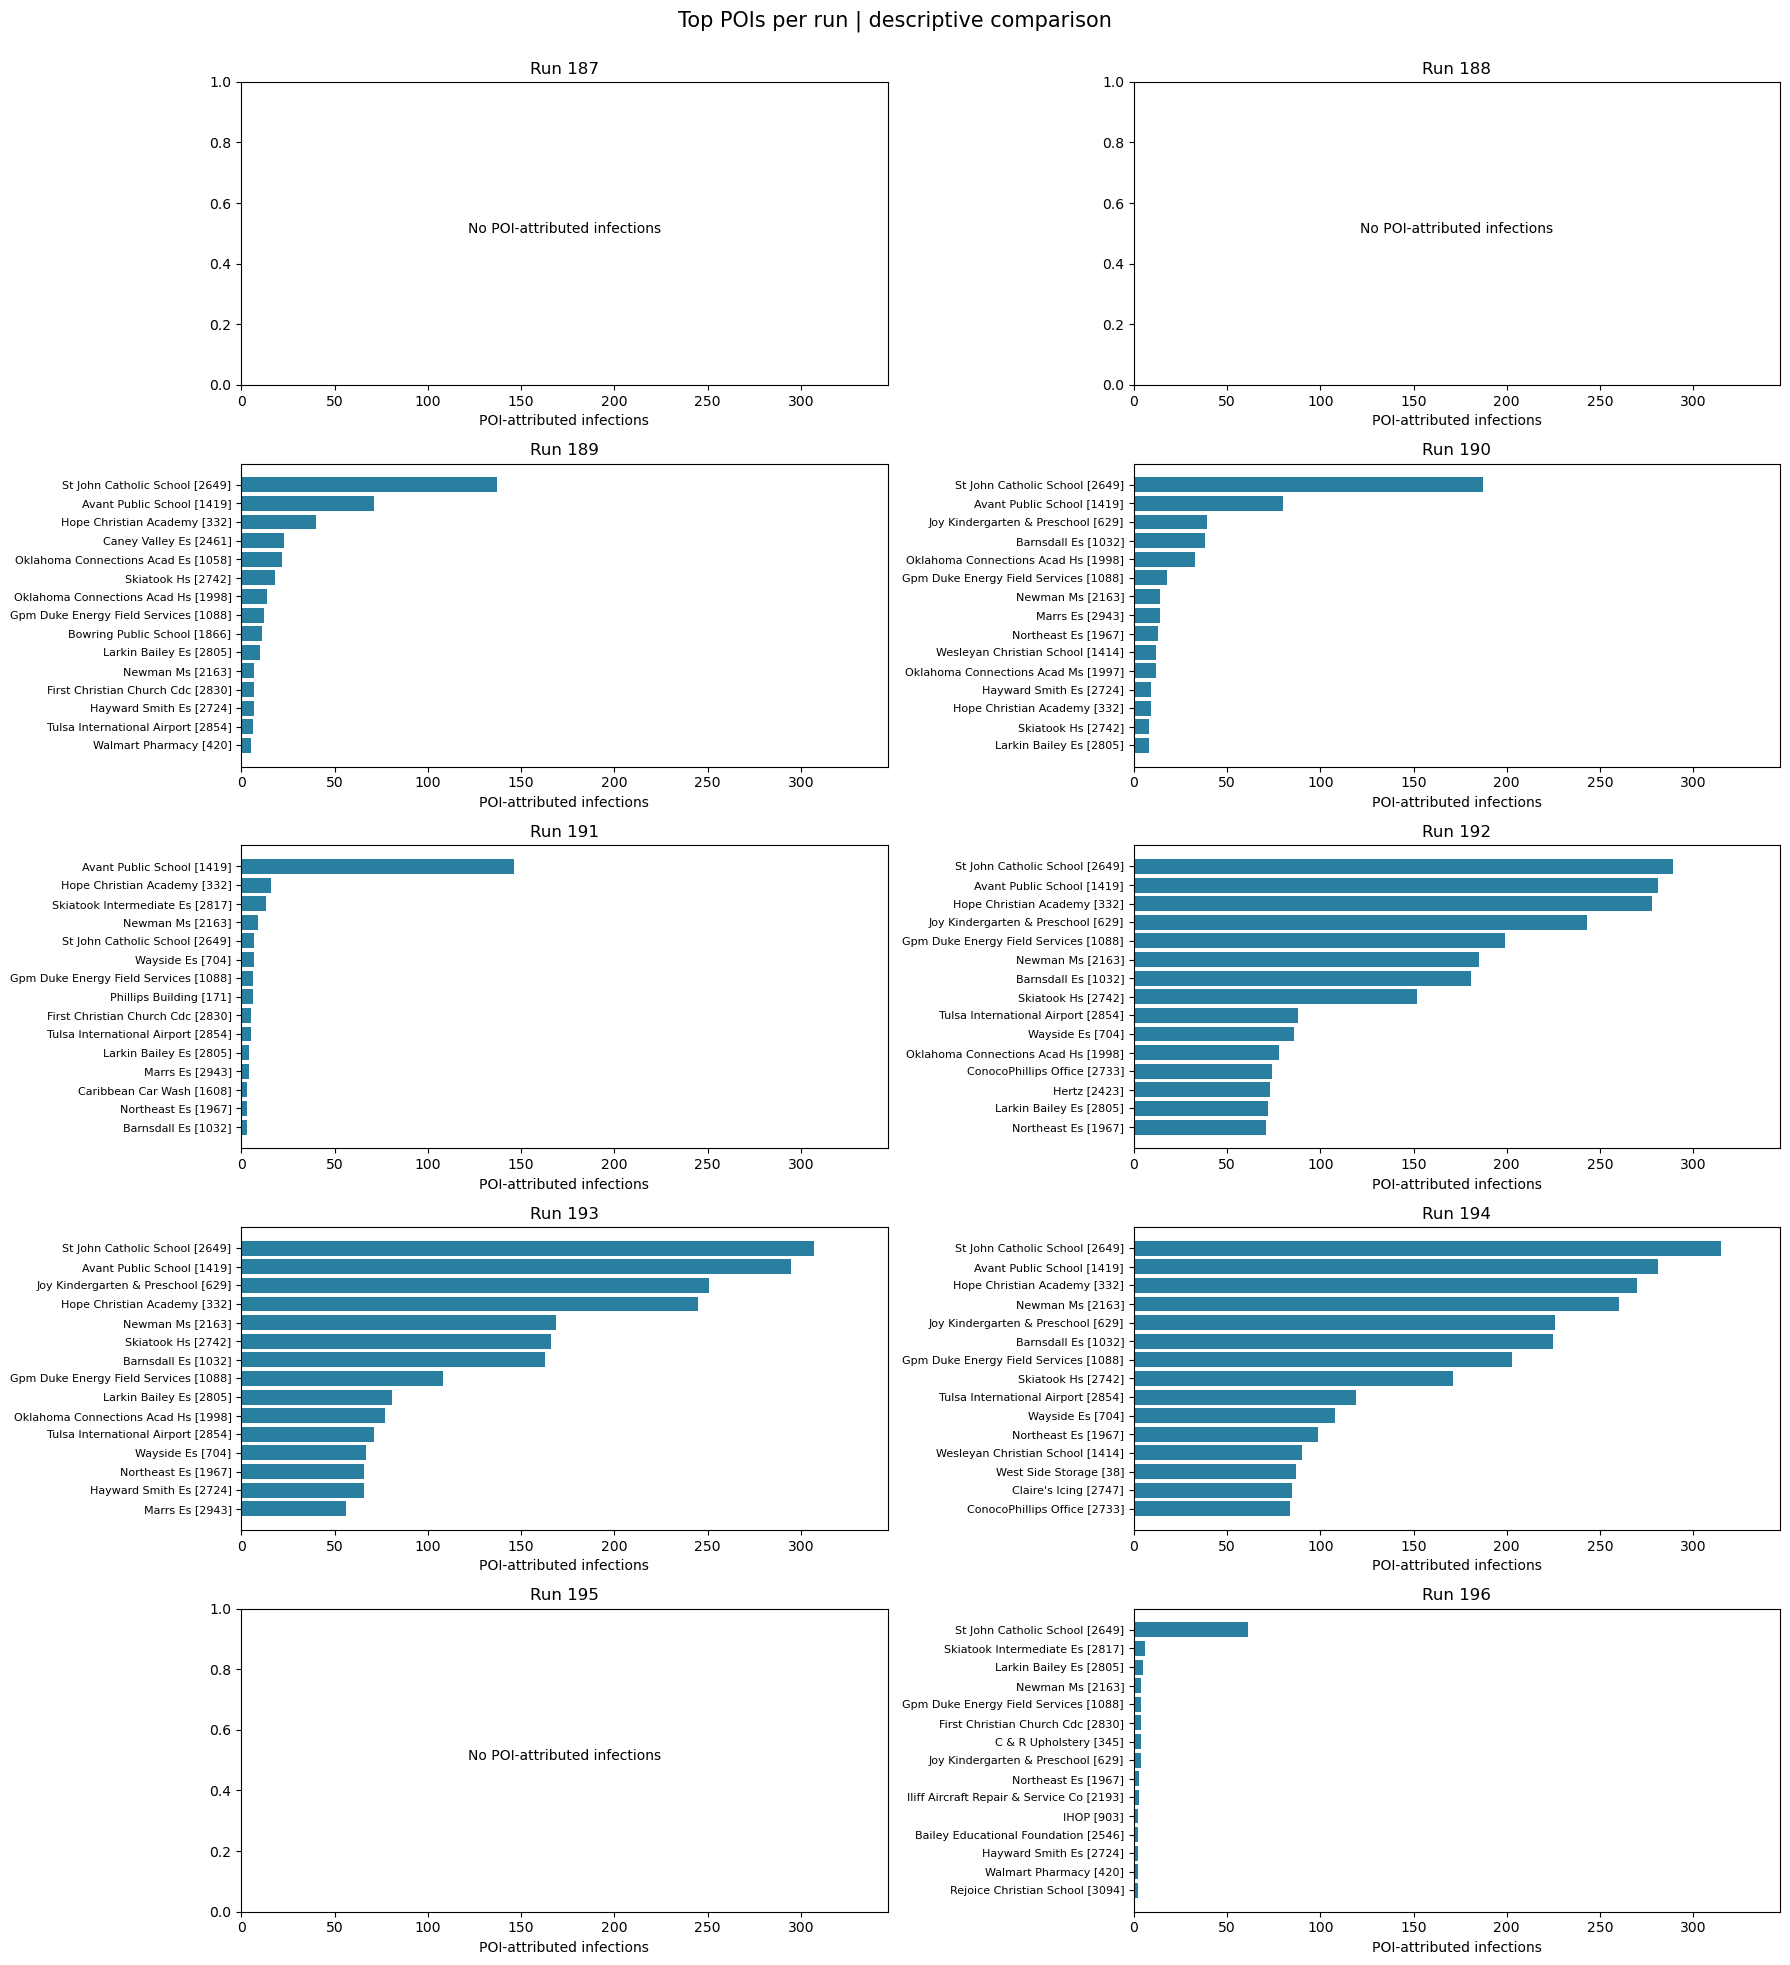

In [12]:
# Figure 1: each run's Top N POIs to reveal new hotspots; all panels share the same x-axis limits.
fig, axes = plt.subplots(int(np.ceil(len(run_order)/2)), 2,
                         figsize=(18, 4*int(np.ceil(len(run_order)/2))), squeeze=False)
xmax = max(1, float(poi_matrix.max().max()) * 1.1)
for ax, rid in zip(axes.flat, run_order):
    s = poi_matrix[rid]
    s = s[s > 0].sort_values(ascending=False, kind="stable").head(TOP_N).sort_values()
    if s.empty:
        ax.text(.5, .5, "No POI-attributed infections", ha="center", transform=ax.transAxes)
    else:
        ax.barh(range(len(s)), s.values, color="#297f9f")
        ax.set_yticks(range(len(s)), poi_names(s.index), fontsize=8)
    ax.set(xlim=(0, xmax), title=f"Run {rid}", xlabel="POI-attributed infections")
for ax in list(axes.flat)[len(run_order):]:
    ax.set_visible(False)
fig.suptitle("Top POIs per run | descriptive comparison", fontsize=15)
fig.tight_layout(rect=(0, 0, 1, .98))
save_poi_figure(fig, "01_top_pois")

## Infection reductions relative to the reference run

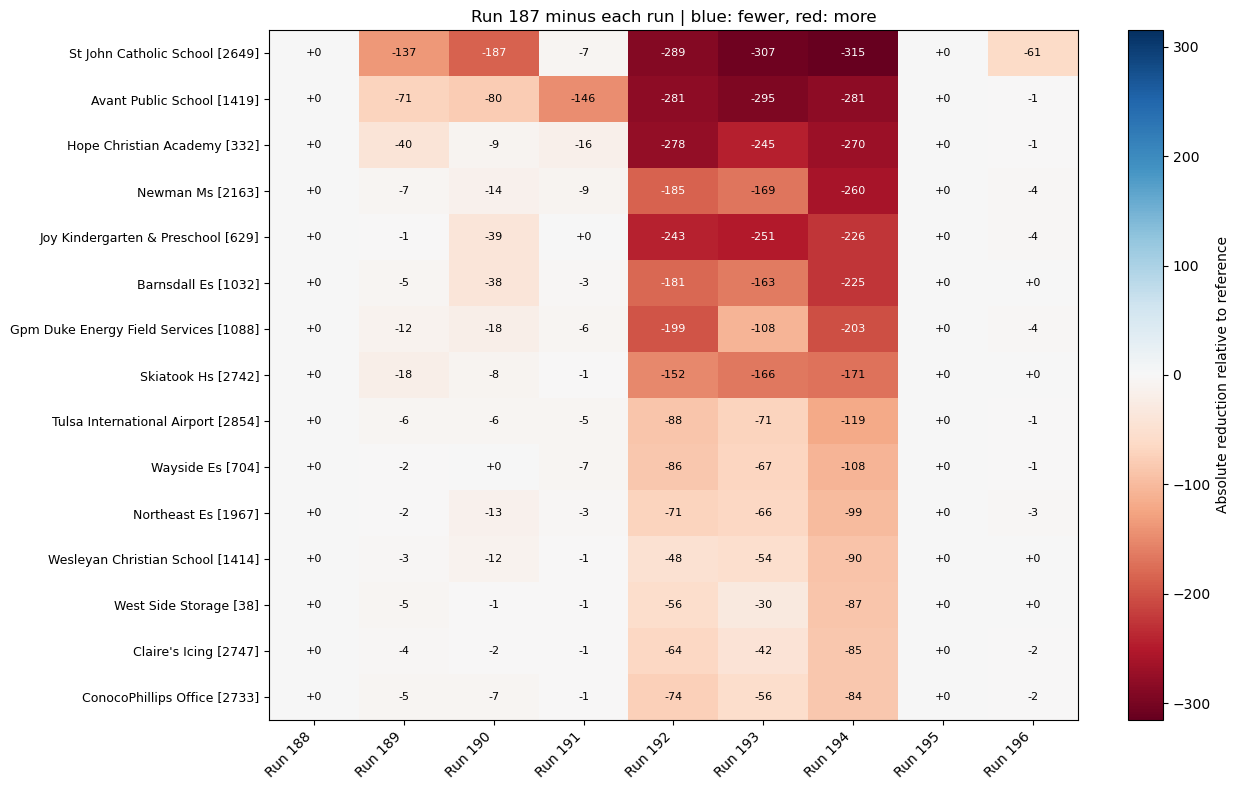

,run_id,placekey,label,reduction


Run 187 has zero POI infections: positive reductions are impossible and percentage reductions are undefined. This plot is not evidence of intervention effectiveness.


In [13]:
# Figure 2: compute differences for all POIs; display a fixed Top N selected by the maximum count across runs.
if BASELINE_RUN_ID not in poi_matrix:
    raise ValueError("BASELINE_RUN_ID is not in the loaded data")
reference = poi_matrix[BASELINE_RUN_ID]
other_runs = [rid for rid in run_order if rid != BASELINE_RUN_ID]
reductions = poi_matrix[other_runs].rsub(reference, axis=0)
reductions.to_csv(POI_OUTPUT_DIR / "poi_absolute_reductions.csv", encoding="utf-8-sig")
percentage_reductions = reductions.div(reference.replace(0, np.nan), axis=0)*100
percentage_reductions.to_csv(POI_OUTPUT_DIR / "poi_percent_reductions.csv", encoding="utf-8-sig")
display_keys = poi_matrix.max(axis=1).sort_values(ascending=False, kind="stable").head(TOP_N).index
matrix = reductions.loc[display_keys]
limit = max(1, float(np.abs(matrix.to_numpy()).max()))
fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(matrix, aspect="auto", cmap="RdBu", norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit))
ax.set_xticks(range(len(other_runs)), [f"Run {r}" for r in other_runs], rotation=45, ha="right")
ax.set_yticks(range(len(display_keys)), poi_names(display_keys), fontsize=9)
for i in range(len(matrix)):
    for j in range(len(other_runs)):
        value = matrix.iloc[i,j]
        ax.text(j,i,f"{value:+.0f}",ha="center",va="center",fontsize=8,
                color="white" if abs(value) > .55*limit else "black")
ax.set_title(f"Run {BASELINE_RUN_ID} minus each run | blue: fewer, red: more")
fig.colorbar(im, ax=ax, label="Absolute reduction relative to reference")
fig.tight_layout()
save_poi_figure(fig, "02_poi_reductions")

# List the largest positive reductions separately; do not describe negative reductions as improvements.
improvement_rows = []
for rid in other_runs:
    s = reductions[rid]
    for k, value in s[s > 0].sort_values(ascending=False).head(TOP_N).items():
        improvement_rows.append(dict(run_id=rid, placekey=k,
                                      label=poi_info.loc[k,"label"], reduction=value))
improvements = pd.DataFrame(improvement_rows, columns=["run_id","placekey","label","reduction"])
display(improvements)
improvements.to_csv(POI_OUTPUT_DIR / "largest_positive_reductions.csv", index=False, encoding="utf-8-sig")
if reference.sum() == 0:
    print(f"Run {BASELINE_RUN_ID} has zero POI infections: positive reductions are impossible and percentage reductions are undefined. This plot is not evidence of intervention effectiveness.")

## Hotspot rank shifts and overlap

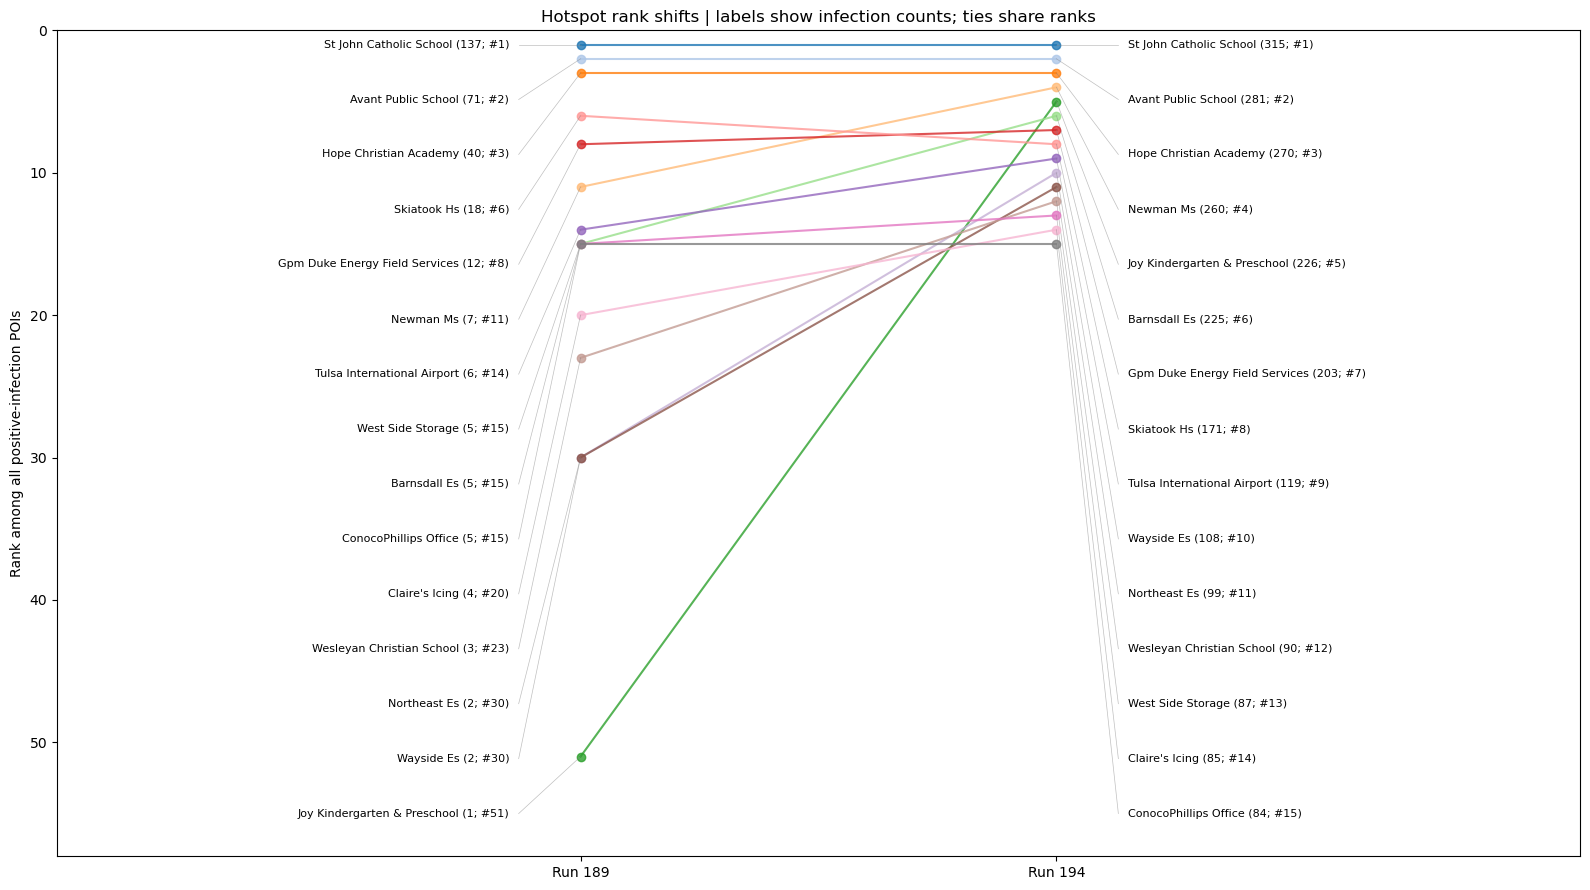

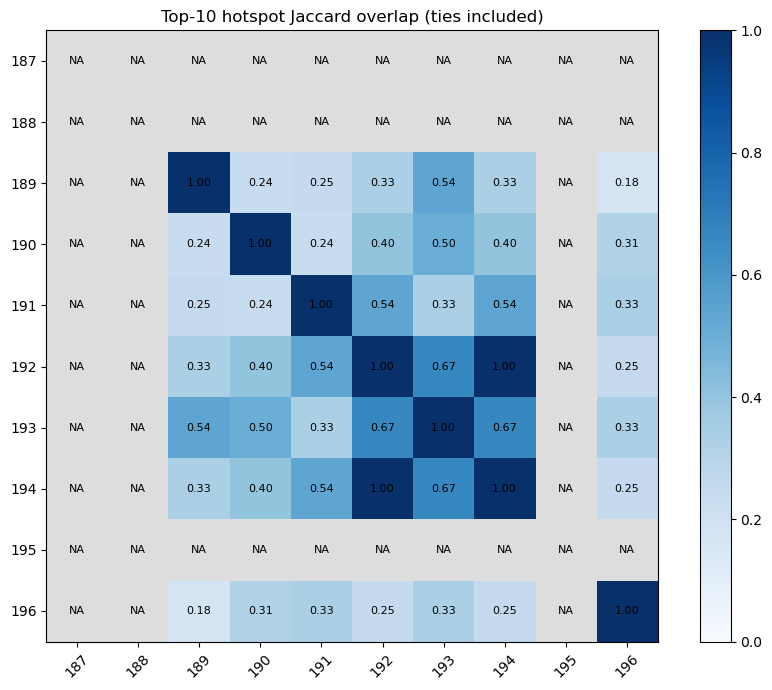

In [14]:
# Figure 3: rank only POIs with positive counts; ties share the minimum rank and zero counts are unranked.
left_id, right_id = RANK_RUN_IDS
if left_id not in poi_matrix or right_id not in poi_matrix:
    raise ValueError("RANK_RUN_IDS must specify two loaded runs")
left, right = poi_matrix[left_id], poi_matrix[right_id]
lr = left.where(left > 0).rank(method="min", ascending=False)
rr = right.where(right > 0).rank(method="min", ascending=False)
keys = poi_matrix[[left_id,right_id]].max(axis=1).sort_values(ascending=False, kind="stable")
keys = keys[keys > 0].head(TOP_N).index
fig, ax = plt.subplots(figsize=(16, 9))
if left.sum() == 0 or right.sum() == 0:
    ax.text(.5,.5,"One run has no POI infections; rank shift is not meaningful.",ha="center",transform=ax.transAxes)
    ax.axis("off")
else:
    maxrank = max(lr.loc[keys].max(),rr.loc[keys].max())
    unranked = maxrank + 5
    label_positions = []
    for ranks in (lr, rr):
        ordered = sorted(keys, key=lambda k: (ranks[k] if pd.notna(ranks[k]) else unranked, k))
        label_positions.append(dict(zip(ordered, np.linspace(1, unranked-1, len(ordered)))))
    for n,k in enumerate(keys):
        a,b = lr[k],rr[k]
        y1,y2 = a if pd.notna(a) else unranked, b if pd.notna(b) else unranked
        ax.plot([0,1],[y1,y2],"o-",color=plt.get_cmap("tab20")(n%20),alpha=.8)
        name = str(poi_info.loc[k,"label"])
        lpos,rpos=label_positions[0][k],label_positions[1][k]
        ax.plot([-.13,0],[lpos,y1],color="gray",lw=.5,alpha=.5)
        ax.plot([1,1.13],[y2,rpos],color="gray",lw=.5,alpha=.5)
        lrank=f"#{a:.0f}" if pd.notna(a) else "unranked"
        rrank=f"#{b:.0f}" if pd.notna(b) else "unranked"
        ax.text(-.15,lpos,f"{name[:32]} ({left[k]:.0f}; {lrank})",ha="right",va="center",fontsize=8)
        ax.text(1.15,rpos,f"{name[:32]} ({right[k]:.0f}; {rrank})",ha="left",va="center",fontsize=8)
    ax.set(xlim=(-1.1,2.1),ylim=(unranked+2,0),ylabel="Rank among all positive-infection POIs")
    ax.set_xticks([0,1],[f"Run {left_id}",f"Run {right_id}"])
    ax.set_title("Hotspot rank shifts | labels show infection counts; ties share ranks")
fig.tight_layout()
save_poi_figure(fig,"03_rank_shifts")
rank_table = pd.DataFrame({"label":poi_info["label"],f"rank_{left_id}":lr,
                           f"rank_{right_id}":rr,f"count_{left_id}":left,f"count_{right_id}":right})
rank_table.to_csv(POI_OUTPUT_DIR / "rank_changes.csv",encoding="utf-8-sig")

# The Top 10 set includes all ties at the cutoff; Jaccard is NA if either set is empty.
top_sets = {}
for rid in run_order:
    s = poi_matrix[rid]; positive = s[s>0]
    cutoff = positive.nlargest(10).min() if not positive.empty else np.nan
    top_sets[rid] = set(positive[positive>=cutoff].index)
overlap = pd.DataFrame(np.nan,index=run_order,columns=run_order)
for a in run_order:
    for b in run_order:
        if top_sets[a] and top_sets[b]:
            overlap.loc[a,b] = len(top_sets[a]&top_sets[b])/len(top_sets[a]|top_sets[b])
fig,ax=plt.subplots(figsize=(9,7))
cmap=plt.get_cmap("Blues").copy(); cmap.set_bad("#dddddd")
im=ax.imshow(overlap,cmap=cmap,vmin=0,vmax=1)
for i in range(len(run_order)):
    for j in range(len(run_order)):
        v=overlap.iloc[i,j]
        ax.text(j,i,"NA" if pd.isna(v) else f"{v:.2f}",ha="center",va="center",fontsize=8)
ax.set_xticks(range(len(run_order)),run_order,rotation=45)
ax.set_yticks(range(len(run_order)),run_order)
ax.set_title("Top-10 hotspot Jaccard overlap (ties included)")
fig.colorbar(im,ax=ax); fig.tight_layout()
save_poi_figure(fig,"04_hotspot_overlap")
overlap.to_csv(POI_OUTPUT_DIR / "hotspot_overlap.csv")

## Transmission composition by Home/POI and category

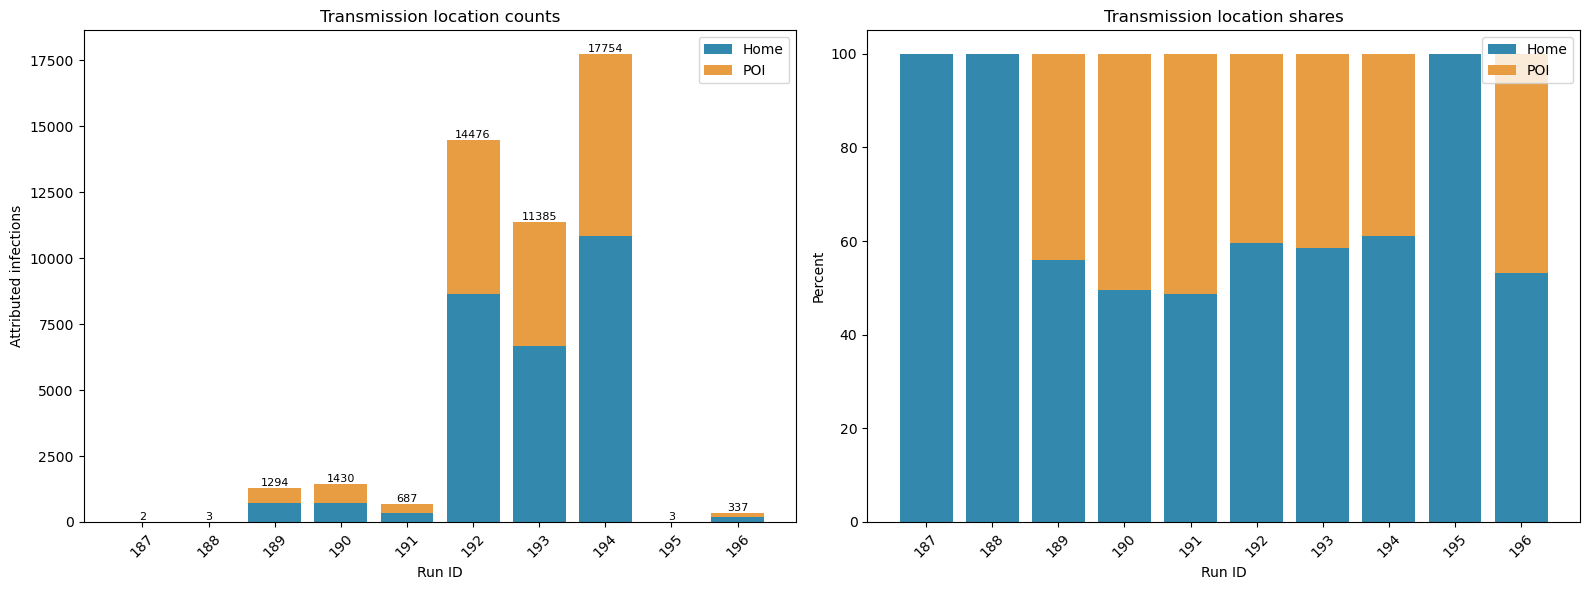

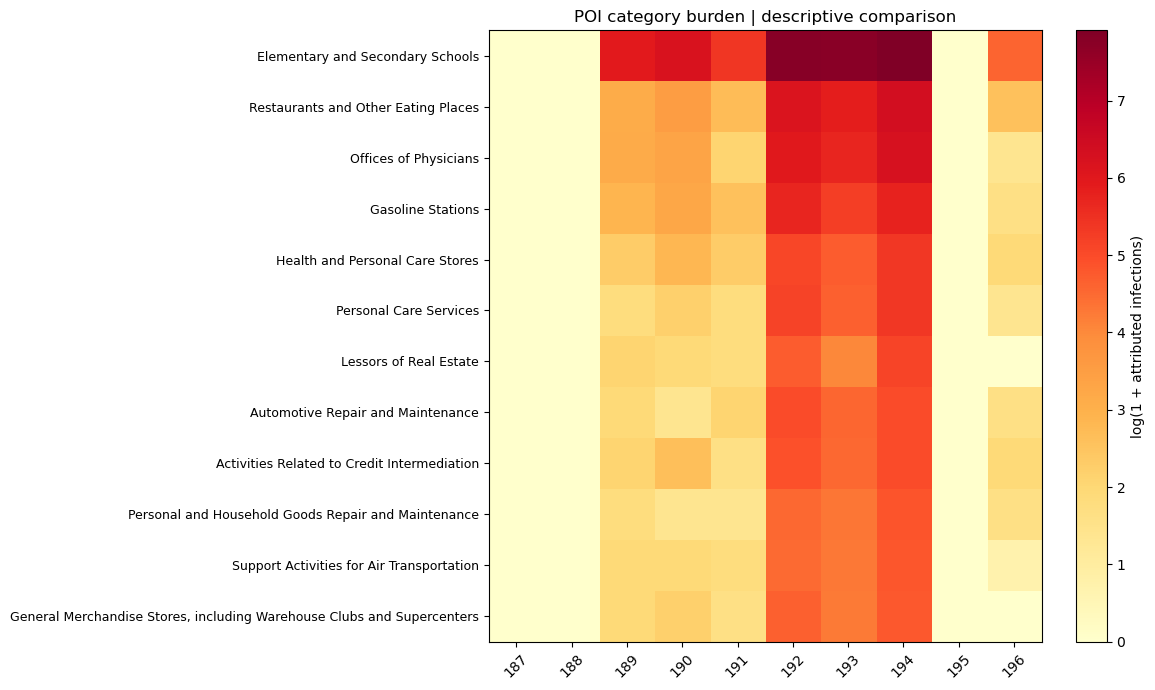

Figures and data saved to:  C:\Users\ZZKT1\Desktop\LIAR\Grads 26 fall\Delineo\delineo_exports\poi_comparison


In [15]:
# Figure 5: show both absolute counts and shares. Shares are undefined when the total is zero.
fig,axes=plt.subplots(1,2,figsize=(16,6))
x=np.arange(len(run_order)); totals=transmission_summary["total"]
for ax,percent in zip(axes,[False,True]):
    home=transmission_summary["home"]
    poi=transmission_summary["poi"]
    if percent:
        home=100*home/totals.replace(0,np.nan)
        poi=100*poi/totals.replace(0,np.nan)
    ax.bar(x,home,label="Home",color="#3288ad")
    ax.bar(x,poi,bottom=home,label="POI",color="#e99d43")
    ax.set_xticks(x,[str(r) for r in run_order],rotation=45)
    ax.set(xlabel="Run ID",ylabel="Percent" if percent else "Attributed infections",
           title="Transmission location shares" if percent else "Transmission location counts")
    if percent: ax.set_ylim(0,105)
    else:
        for i,total in enumerate(totals):
            ax.text(i,total,f"{total:.0f}",ha="center",va="bottom",fontsize=8)
    ax.legend()
fig.tight_layout(); save_poi_figure(fig,"05_home_poi")

# Figure 6: category burden for a fixed set of top categories; log1p is used only for the color scale, while CSV files retain raw counts.
category_matrix=poi_counts.groupby(["top_category","run_id"])["infections"].sum().unstack("run_id").reindex(columns=run_order)
category_matrix.to_csv(POI_OUTPUT_DIR / "category_counts.csv",encoding="utf-8-sig")
top_categories=category_matrix.max(axis=1).nlargest(12).index
fig,ax=plt.subplots(figsize=(12,7))
im=ax.imshow(np.log1p(category_matrix.loc[top_categories]),aspect="auto",cmap="YlOrRd")
ax.set_xticks(range(len(run_order)),run_order,rotation=45)
ax.set_yticks(range(len(top_categories)),top_categories,fontsize=9)
ax.set_title("POI category burden | descriptive comparison")
fig.colorbar(im,ax=ax,label="log(1 + attributed infections)")
fig.tight_layout(); save_poi_figure(fig,"06_category_patterns")
print("Figures and data saved to: ", POI_OUTPUT_DIR.resolve())